In [1]:
import rerun as rr
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# Load the recording
recording = rr.dataframe.load_recording("alumnium_sheets.rrd")

C:\Users\gauth\AppData\Local\Temp\ipykernel_3568\3102923775.py:2: DeprecationWarning: `rerun.dataframe.load_recording` is deprecated. Use `rerun.recording.load_recording` instead. See: https://rerun.io/docs/reference/migration/migration-0-28#recordingview-and-local-dataframe-api-deprecated
  recording = rr.dataframe.load_recording("alumnium_sheets.rrd")


In [3]:
# Get the heatmap data
view = recording.view(index="timestamp", contents="radar/heatmap_3d")
table = view.select().read_all()

In [4]:
# Get the tensor column (note the leading slash)
tensor_column = table.column("/radar/heatmap_3d:Tensor:data")

In [5]:
# Extract numpy arrays
heatmaps = []
for batch in tensor_column:
    for item in batch:
        if item is not None:
            # Get shape and buffer directly
            shape = item["shape"].as_py()  # [10, 32, 16]
            buffer = item["buffer"].as_py()  # list of floats
            
            # Convert to numpy and reshape
            arr = np.array(buffer, dtype=np.float32).reshape(shape)
            heatmaps.append(arr)

heatmaps = np.array(heatmaps)
print(f"Shape: {heatmaps.shape}")  # Should be (num_frames, 10, 32, 16)



Shape: (124, 10, 32, 16)


In [6]:
# Save
np.save("aluminium_sheets_sticked.npy", heatmaps)
print("Saved!")

Saved!


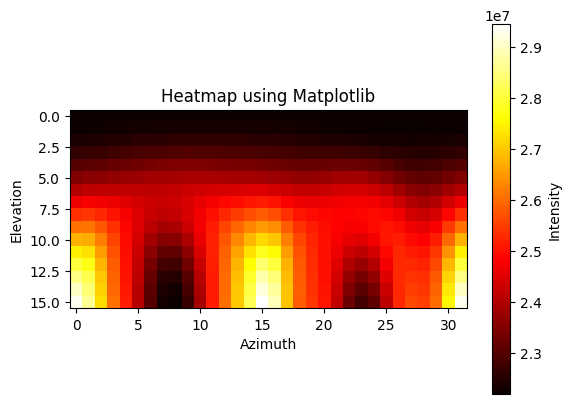

In [7]:
heatmaps[0,1].shape
capon4 = np.mean(heatmaps, axis=0)
data = np.array(capon4).reshape((10,32,16))
radiation_pattern = data

data = radiation_pattern
data = np.rot90(m=radiation_pattern, axes=(2,1))

plt.imshow(data[0], cmap='hot', interpolation='nearest')
plt.colorbar(label='Intensity')
plt.title('Heatmap using Matplotlib')
plt.xlabel('Azimuth')
plt.ylabel('Elevation')
plt.show()

In [8]:
np.save("alumnium_mean.npy", heatmaps)
print("Saved!")

Saved!
